In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

print("Environment ready")


Environment ready


In [2]:
PROJECT_ROOT = Path.cwd().parent
RAW_DATA = PROJECT_ROOT / "data" / "raw"

print("Project root:", PROJECT_ROOT)
print("Raw data:", RAW_DATA)

Project root: /Users/haarik/ecommerce-data-engineering
Raw data: /Users/haarik/ecommerce-data-engineering/data/raw


In [3]:
customers = pd.read_csv(RAW_DATA / "olist_customers_dataset.csv")
geolocation = pd.read_csv(RAW_DATA / "olist_geolocation_dataset.csv")
orders = pd.read_csv(RAW_DATA / "olist_orders_dataset.csv")
order_items = pd.read_csv(RAW_DATA / "olist_order_items_dataset.csv")
payments = pd.read_csv(RAW_DATA / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(RAW_DATA / "olist_order_reviews_dataset.csv")
products = pd.read_csv(RAW_DATA / "olist_products_dataset.csv")
sellers = pd.read_csv(RAW_DATA / "olist_sellers_dataset.csv")
category_translation = pd.read_csv(
    RAW_DATA / "product_category_name_translation.csv"
)

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [4]:
datasets = {
    "customers": customers,
    "geolocation": geolocation,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

for name, df in datasets.items():
    print(f"{name:20} {df.shape}")

customers            (99441, 5)
geolocation          (1000163, 5)
orders               (99441, 8)
order_items          (112650, 7)
payments             (103886, 5)
reviews              (99224, 7)
products             (32951, 9)
sellers              (3095, 4)
category_translation (71, 2)


In [5]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("-" * 50)
    print(df.columns.tolist())


CUSTOMERS
--------------------------------------------------
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

GEOLOCATION
--------------------------------------------------
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

ORDERS
--------------------------------------------------
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

ORDER_ITEMS
--------------------------------------------------
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

PAYMENTS
--------------------------------------------------
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

REVIEWS
--------------------------------------------------
['review_id', 'order_id', 're

In [6]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    display(df.head())


CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



GEOLOCATION


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP



ORDERS


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



SELLERS


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



CATEGORY_TRANSLATION


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [7]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("-" * 50)
    print(df.dtypes)


CUSTOMERS
--------------------------------------------------
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

GEOLOCATION
--------------------------------------------------
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                   str
geolocation_state                  str
dtype: object

ORDERS
--------------------------------------------------
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

ORDER_ITEMS
--------------------------------------------------
order_id                   str
order_item_id    

In [8]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("-" * 50)
    print(df.dtypes.to_string())


CUSTOMERS
--------------------------------------------------
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str

GEOLOCATION
--------------------------------------------------
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                   str
geolocation_state                  str

ORDERS
--------------------------------------------------
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str

ORDER_ITEMS
--------------------------------------------------
order_id                   str
order_item_id            int64
product_id                 s

In [9]:
missing_summary = []

for name, df in datasets.items():
    missing_count = df.isnull().sum().sum()
    total_cells = df.shape[0] * df.shape[1]
    missing_percentage = (missing_count / total_cells) * 100

    missing_summary.append({
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_values": missing_count,
        "missing_percentage": round(missing_percentage, 2)
    })

missing_df = pd.DataFrame(missing_summary)

missing_df


,dataset,rows,columns,missing_values,missing_percentage
0,customers,99441,5,0,0.00
1,geolocation,1000163,5,0,0.00
2,orders,99441,8,4908,0.62
3,order_items,112650,7,0,0.00
4,payments,103886,5,0,0.00
5,reviews,99224,7,145903,21.01
6,products,32951,9,2448,0.83
7,sellers,3095,4,0,0.00
8,category_translation,71,2,0,0.00


In [10]:
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    print(f"\n{name.upper()}")
    print("-" * 50)

    if len(missing) == 0:
        print("No missing values")
    else:
        print(missing)


CUSTOMERS
--------------------------------------------------
No missing values

GEOLOCATION
--------------------------------------------------
No missing values

ORDERS
--------------------------------------------------
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
dtype: int64

ORDER_ITEMS
--------------------------------------------------
No missing values

PAYMENTS
--------------------------------------------------
No missing values

REVIEWS
--------------------------------------------------
review_comment_title      87656
review_comment_message    58247
dtype: int64

PRODUCTS
--------------------------------------------------
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

SELLERS

In [11]:
for name, df in datasets.items():
    missing = (
        df.isnull()
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    missing = missing[missing > 0]

    if len(missing) > 0:
        print(f"\n{name.upper()}")
        print("-" * 50)
        print(missing.round(2))


ORDERS
--------------------------------------------------
order_delivered_customer_date    2.98
order_delivered_carrier_date     1.79
order_approved_at                0.16
dtype: float64

REVIEWS
--------------------------------------------------
review_comment_title      88.34
review_comment_message    58.70
dtype: float64

PRODUCTS
--------------------------------------------------
product_category_name         1.85
product_name_lenght           1.85
product_description_lenght    1.85
product_photos_qty            1.85
product_weight_g              0.01
product_length_cm             0.01
product_height_cm             0.01
product_width_cm              0.01
dtype: float64


In [12]:
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) > 0:
        print(f"\n{name.upper()}")
        print("-" * 50)

        for column, count in missing.items():
            percentage = (count / len(df)) * 100
            print(f"{column:40} {count:8} ({percentage:6.2f}%)")


ORDERS
--------------------------------------------------
order_approved_at                             160 (  0.16%)
order_delivered_carrier_date                 1783 (  1.79%)
order_delivered_customer_date                2965 (  2.98%)

REVIEWS
--------------------------------------------------
review_comment_title                        87656 ( 88.34%)
review_comment_message                      58247 ( 58.70%)

PRODUCTS
--------------------------------------------------
product_category_name                         610 (  1.85%)
product_name_lenght                           610 (  1.85%)
product_description_lenght                    610 (  1.85%)
product_photos_qty                            610 (  1.85%)
product_weight_g                                2 (  0.01%)
product_length_cm                               2 (  0.01%)
product_height_cm                               2 (  0.01%)
product_width_cm                                2 (  0.01%)


In [13]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [14]:
orders["order_status"].value_counts(normalize=True).mul(100).round(2)

order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

In [15]:
orders.groupby("order_status").agg(
    total_orders=("order_id", "count"),
    missing_delivered_date=("order_delivered_customer_date", lambda x: x.isnull().sum()),
    missing_carrier_date=("order_delivered_carrier_date", lambda x: x.isnull().sum())
)

,total_orders,missing_delivered_date,missing_carrier_date
order_status,,,
approved,2,2,2
canceled,625,619,550
created,5,5,5
delivered,96478,8,2
invoiced,314,314,314
processing,301,301,301
shipped,1107,1107,0
unavailable,609,609,609


In [16]:
for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    print(f"{name:20} {duplicates:,} duplicate rows")

customers            0 duplicate rows
geolocation          261,831 duplicate rows
orders               0 duplicate rows
order_items          0 duplicate rows
payments             0 duplicate rows
reviews              0 duplicate rows
products             0 duplicate rows
sellers              0 duplicate rows
category_translation 0 duplicate rows


In [17]:
key_columns = {
    "customers": ["customer_id", "customer_unique_id"],
    "orders": ["order_id", "customer_id"],
    "order_items": ["order_id"],
    "payments": ["order_id"],
    "products": ["product_id"],
    "sellers": ["seller_id"],
    "reviews": ["review_id", "order_id"]
}

for dataset_name, columns in key_columns.items():
    df = datasets[dataset_name]

    print(f"\n{dataset_name.upper()}")
    print("-" * 50)

    for column in columns:
        print(
            f"{column:30} "
            f"unique={df[column].nunique():,} | "
            f"rows={len(df):,}"
        )


CUSTOMERS
--------------------------------------------------
customer_id                    unique=99,441 | rows=99,441
customer_unique_id             unique=96,096 | rows=99,441

ORDERS
--------------------------------------------------
order_id                       unique=99,441 | rows=99,441
customer_id                    unique=99,441 | rows=99,441

ORDER_ITEMS
--------------------------------------------------
order_id                       unique=98,666 | rows=112,650

PAYMENTS
--------------------------------------------------
order_id                       unique=99,440 | rows=103,886

PRODUCTS
--------------------------------------------------
product_id                     unique=32,951 | rows=32,951

SELLERS
--------------------------------------------------
seller_id                      unique=3,095 | rows=3,095

REVIEWS
--------------------------------------------------
review_id                      unique=98,410 | rows=99,224
order_id                       unique=98,6

In [18]:
order_item_counts = order_items.groupby("order_id").size()

print("Orders with items:", order_item_counts.shape[0])
print("Maximum items in one order:", order_item_counts.max())
print("Average items per order:", round(order_item_counts.mean(), 2))

Orders with items: 98666
Maximum items in one order: 21
Average items per order: 1.14


In [19]:
order_status_summary = (
    orders["order_status"]
    .value_counts()
    .reset_index()
)

order_status_summary.columns = ["order_status", "order_count"]

order_status_summary["percentage"] = (
    order_status_summary["order_count"]
    / len(orders)
    * 100
).round(2)

order_status_summary

,order_status,order_count,percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


In [20]:
customer_state_summary = (
    customers["customer_state"]
    .value_counts()
    .reset_index()
)

customer_state_summary.columns = ["state", "customer_count"]

customer_state_summary.head(10)

,state,customer_count
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


In [21]:
products["product_category_name"].nunique()

73

In [22]:
product_category_summary = (
    products["product_category_name"]
    .value_counts()
    .reset_index()
)

product_category_summary.columns = [
    "product_category",
    "product_count"
]

product_category_summary.head(15)

,product_category,product_count
0,cama_mesa_banho,3029
1,esporte_lazer,2867
2,moveis_decoracao,2657
3,beleza_saude,2444
4,utilidades_domesticas,2335
5,automotivo,1900
6,informatica_acessorios,1639
7,brinquedos,1411
8,relogios_presentes,1329
9,telefonia,1134


In [23]:
payment_summary = (
    payments["payment_type"]
    .value_counts()
    .reset_index()
)

payment_summary.columns = [
    "payment_type",
    "payment_count"
]

payment_summary["percentage"] = (
    payment_summary["payment_count"]
    / len(payments)
    * 100
).round(2)

payment_summary

,payment_type,payment_count,percentage
0,credit_card,76795,73.92
1,boleto,19784,19.04
2,voucher,5775,5.56
3,debit_card,1529,1.47
4,not_defined,3,0.00


In [24]:
# Check the payment columns first
payments.columns.tolist()

['order_id',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value']

In [25]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [26]:
order_id
payment_value

NameError: name 'order_id' is not defined

In [27]:
payments.columns.tolist()

['order_id',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value']

In [28]:
payments.head(10)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
5,298fcdf1f73eb413e4d26d01b25bc1cd,1,credit_card,2,96.12
6,771ee386b001f06208a7419e4fc1bbd7,1,credit_card,1,81.16
7,3d7239c394a212faae122962df514ac7,1,credit_card,3,51.84
8,1f78449c87a54faf9e96e88ba1491fa9,1,credit_card,6,341.09
9,0573b5e23cbd798006520e1d5b4c6714,1,boleto,1,51.95


In [29]:
total_revenue = payments["payment_value"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $16,008,872.12


In [30]:
order_payments = (
    payments
    .groupby("order_id", as_index=False)["payment_value"]
    .sum()
)

aov = order_payments["payment_value"].mean()

print(f"Number of orders with payments: {len(order_payments):,}")
print(f"Average Order Value: ${aov:,.2f}")

Number of orders with payments: 99,440
Average Order Value: $160.99


In [31]:
monthly_revenue = orders[["order_id", "order_purchase_timestamp"]].copy()

monthly_revenue["order_purchase_timestamp"] = pd.to_datetime(
    monthly_revenue["order_purchase_timestamp"]
)

monthly_revenue = monthly_revenue.merge(
    order_payments,
    on="order_id",
    how="inner"
)

monthly_revenue["month"] = (
    monthly_revenue["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

monthly_revenue = (
    monthly_revenue
    .groupby("month", as_index=False)["payment_value"]
    .sum()
)

monthly_revenue.columns = ["month", "revenue"]

monthly_revenue.head(10)

,month,revenue
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01
5,2017-03,449863.60
6,2017-04,417788.03
7,2017-05,592918.82
8,2017-06,511276.38
9,2017-07,592382.92


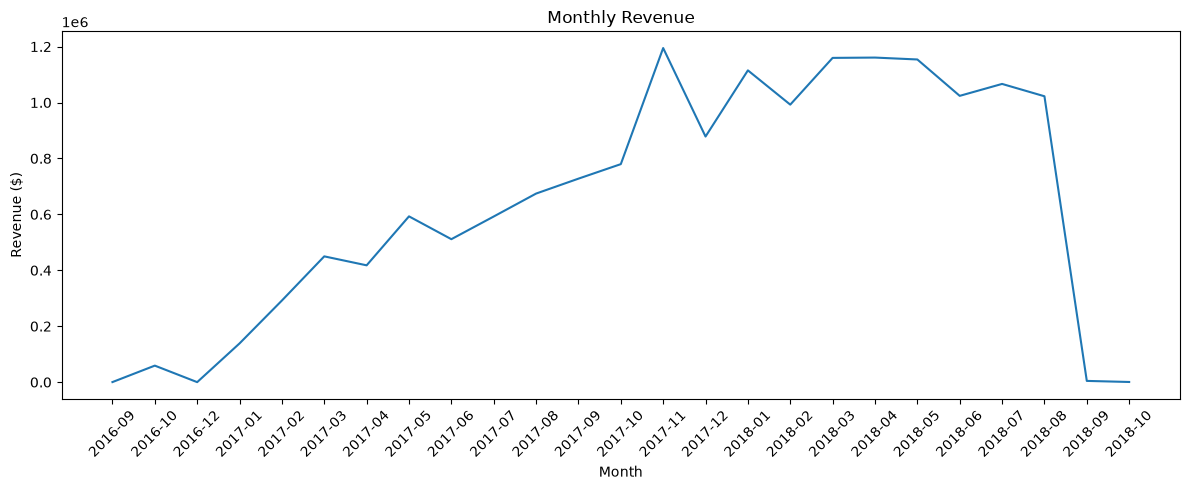

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["revenue"]
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
products.columns.tolist()

['product_id',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

In [35]:
category_revenue = order_items[
    ["order_id", "product_id", "price"]
].merge(
    products[
        ["product_id", "product_category_name"]
    ],
    on="product_id",
    how="left"
)

category_revenue.head()

,order_id,product_id,price,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.90,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.90,pet_shop
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,199.00,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,12.99,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,199.90,ferramentas_jardim


In [36]:
category_revenue_summary = (
    category_revenue
    .groupby("product_category_name", as_index=False)["price"]
    .sum()
    .sort_values("price", ascending=False)
)

category_revenue_summary.head(10)

,product_category_name,price
11,beleza_saude,1258681.34
66,relogios_presentes,1205005.68
13,cama_mesa_banho,1036988.68
32,esporte_lazer,988048.97
44,informatica_acessorios,911954.32
54,moveis_decoracao,729762.49
26,cool_stuff,635290.85
72,utilidades_domesticas,632248.66
8,automotivo,592720.11
40,ferramentas_jardim,485256.46


In [37]:
category_translation.head(10)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
5,esporte_lazer,sports_leisure
6,perfumaria,perfumery
7,utilidades_domesticas,housewares
8,telefonia,telephony
9,relogios_presentes,watches_gifts


In [38]:
category_revenue_summary = category_revenue_summary.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

category_revenue_summary.head(10)

,product_category_name,price,product_category_name_english
0,beleza_saude,1258681.34,health_beauty
1,relogios_presentes,1205005.68,watches_gifts
2,cama_mesa_banho,1036988.68,bed_bath_table
3,esporte_lazer,988048.97,sports_leisure
4,informatica_acessorios,911954.32,computers_accessories
5,moveis_decoracao,729762.49,furniture_decor
6,cool_stuff,635290.85,cool_stuff
7,utilidades_domesticas,632248.66,housewares
8,automotivo,592720.11,auto
9,ferramentas_jardim,485256.46,garden_tools


In [39]:
top_categories = (
    category_revenue_summary[
        ["product_category_name_english", "price"]
    ]
    .rename(
        columns={
            "product_category_name_english": "category",
            "price": "revenue"
        }
    )
    .head(10)
)

top_categories

,category,revenue
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46


In [40]:
customer_state_distribution = (
    customers["customer_state"]
    .value_counts()
    .reset_index()
)

customer_state_distribution.columns = ["state", "customer_count"]

customer_state_distribution.head(10)

,state,customer_count
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


In [41]:
customer_state_distribution["percentage"] = (
    customer_state_distribution["customer_count"]
    / customer_state_distribution["customer_count"].sum()
    * 100
)

customer_state_distribution.head(10)

,state,customer_count,percentage
0,SP,41746,41.980672
1,RJ,12852,12.924247
2,MG,11635,11.700405
3,RS,5466,5.496727
4,PR,5045,5.073360
5,SC,3637,3.657445
6,BA,3380,3.399000
7,DF,2140,2.152030
8,ES,2033,2.044428
9,GO,2020,2.031355


In [42]:
orders_without_items = orders[
    ~orders["order_id"].isin(order_items["order_id"])
]

print("Orders without items:", len(orders_without_items))

orders_without_items["order_status"].value_counts()

Orders without items: 775


order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

In [43]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [44]:
missing_summary

[{'dataset': 'customers',
  'rows': 99441,
  'columns': 5,
  'missing_values': np.int64(0),
  'missing_percentage': np.float64(0.0)},
 {'dataset': 'geolocation',
  'rows': 1000163,
  'columns': 5,
  'missing_values': np.int64(0),
  'missing_percentage': np.float64(0.0)},
 {'dataset': 'orders',
  'rows': 99441,
  'columns': 8,
  'missing_values': np.int64(4908),
  'missing_percentage': np.float64(0.62)},
 {'dataset': 'order_items',
  'rows': 112650,
  'columns': 7,
  'missing_values': np.int64(0),
  'missing_percentage': np.float64(0.0)},
 {'dataset': 'payments',
  'rows': 103886,
  'columns': 5,
  'missing_values': np.int64(0),
  'missing_percentage': np.float64(0.0)},
 {'dataset': 'reviews',
  'rows': 99224,
  'columns': 7,
  'missing_values': np.int64(145903),
  'missing_percentage': np.float64(21.01)},
 {'dataset': 'products',
  'rows': 32951,
  'columns': 9,
  'missing_values': np.int64(2448),
  'missing_percentage': np.float64(0.83)},
 {'dataset': 'sellers',
  'rows': 3095,
  'col